# Food Category + Portion Size Calorie Pipeline

This notebook builds the main project model pipeline:

1. Train a Food-101 subset food classifier.
2. Train a portion classifier on the valid portion-labeled images.
3. Combine predicted food and predicted portion with a rule-based calorie map.
4. Train a Nutrition5k direct calorie-level baseline.
5. Save model checkpoints, confusion matrices, metrics CSVs, and example final predictions.

Expected data layout:

```text
data/
  food101_labels_final.csv
  portion_labeling_clean.csv
  food101_subset/
    burger/
    pasta/
    pizza/
    salad/
    sushi/
  nutrition5k/
    nutrition5k_labels.csv
    images/
```

If your image folder is somewhere else, change `IMAGE_BASE_DIR` in the config cell.


## 1. Imports and configuration

In [2]:
from pathlib import Path
import copy
import os
import random
from typing import Dict, List, Tuple

try:
    import numpy as np
    import pandas as pd
    from PIL import Image
    import matplotlib.pyplot as plt

    import torch
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import transforms
    from torchvision.models import (
        EfficientNet_B0_Weights,
        ResNet18_Weights,
        efficientnet_b0,
        resnet18,
    )

    from sklearn.metrics import (
        ConfusionMatrixDisplay,
        accuracy_score,
        classification_report,
        confusion_matrix,
    )
    from tqdm.auto import tqdm
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing a required package. Run the optional install cell above, then restart the kernel."
    ) from exc

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FOOD_CSV = DATA_DIR / "food101_labels_final.csv"
PORTION_CSV = DATA_DIR / "portion_labeling_clean.csv"
NUTRITION5K_CSV = DATA_DIR / "nutrition5k" / "nutrition5k_labels.csv"

FOOD_CLASSES = ["burger", "pasta", "pizza", "salad", "sushi"]
PORTION_CLASSES = ["small", "medium", "large"]
CALORIE_CLASSES = ["low", "medium", "high"]

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
PORTION_BATCH_SIZE = 16
NUM_WORKERS = 0 if os.name == "nt" else 2

FOOD_RESNET18_EPOCHS = 5
FOOD_EFFICIENTNET_EPOCHS = 8
PORTION_EPOCHS = 10
NUTRITION5K_EPOCHS = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Using device: {DEVICE}")


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


set_seed(SEED)



Project root: C:\Users\Kai Xu\PycharmProjects\ECS111Final
Data directory: C:\Users\Kai Xu\PycharmProjects\ECS111Final\Data
Using device: cuda


## 2. Load labels and create the clean portion CSV if needed

In [3]:
def require_file(path: Path, description: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"{description} not found: {path}")


require_file(FOOD_CSV, "Food-101 label CSV")
require_file(PORTION_CSV, "Portion label CSV")
require_file(NUTRITION5K_CSV, "Nutrition5k label CSV")

food_df = pd.read_csv(FOOD_CSV)
portion_df = pd.read_csv(PORTION_CSV)
nutrition_df = pd.read_csv(NUTRITION5K_CSV)

food_df = food_df[food_df["food_label"].isin(FOOD_CLASSES)].copy()
portion_df = portion_df[portion_df["portion_label"].isin(PORTION_CLASSES)].copy()

if "calorie_level" not in nutrition_df.columns:
    def calorie_level_from_kcal(calories: float) -> str:
        if calories <= 400:
            return "low"
        if calories <= 800:
            return "medium"
        return "high"

    nutrition_df["calorie_level"] = nutrition_df["calories"].apply(calorie_level_from_kcal)

nutrition_df = nutrition_df[nutrition_df["calorie_level"].isin(CALORIE_CLASSES)].copy()

print("Food rows:", len(food_df))
print("Portion rows:", len(portion_df))
print("Nutrition5k rows:", len(nutrition_df))

display(food_df.groupby(["split", "food_label"]).size().unstack(fill_value=0))
display(portion_df.groupby(["split", "portion_label"]).size().unstack(fill_value=0))
display(nutrition_df.groupby(["split", "calorie_level"]).size().unstack(fill_value=0))



Food rows: 5000
Portion rows: 495
Nutrition5k rows: 211


food_label,burger,pasta,pizza,salad,sushi
split,,,,,
test,100,100,100,100,100
train,800,800,800,800,800
val,100,100,100,100,100


portion_label,large,medium,small
split,,,
test,14,16,15
train,138,141,126
val,14,18,13


calorie_level,high,low,medium
split,,,
test,7,9,10
train,53,50,64
val,5,10,3


## 3. Image path checks

In [4]:
def resolve_image_path(path_value: str) -> Path:
    path = Path(str(path_value))
    if path.is_absolute():
        return path

    parts = list(path.parts)
    if parts and parts[0].lower() == "data":
        path = Path("Data", *parts[1:])

    return PROJECT_ROOT / path


def first_missing_paths(df: pd.DataFrame, limit: int = 10) -> List[Path]:
    missing = []
    for path_value in df["image_path"]:
        image_path = resolve_image_path(path_value)
        if not image_path.exists():
            missing.append(image_path)
            if len(missing) >= limit:
                break
    return missing


def assert_images_exist(dataset_name: str, df: pd.DataFrame) -> None:
    missing = first_missing_paths(df)
    if missing:
        preview = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(
            f"{dataset_name} is missing image files. First missing examples:\n{preview}"
        )


assert_images_exist("Food-101", food_df)
assert_images_exist("Portion", portion_df)
assert_images_exist("Nutrition5k", nutrition_df)
print("All referenced image files were found.")



All referenced image files were found.


## 4. Dataset class, transforms, and DataLoaders

In [5]:
class FoodImageDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        label_col: str,
        class_to_idx: Dict[str, int],
        transform=None,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.label_col = label_col
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image_path = resolve_image_path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = self.class_to_idx[row[self.label_col]]
        return image, label


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

food_train_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

portion_train_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.00), ratio=(0.90, 1.10)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.12, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

nutrition_train_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)


def make_dataloaders(
    df: pd.DataFrame,
    label_col: str,
    classes: List[str],
    train_transform,
    valid_transform,
    batch_size: int,
) -> Dict[str, DataLoader]:
    class_to_idx = {name: idx for idx, name in enumerate(classes)}
    loaders = {}
    for split in ["train", "val", "test"]:
        split_df = df[df["split"] == split].copy()
        transform = train_transform if split == "train" else valid_transform
        dataset = FoodImageDataset(split_df, label_col, class_to_idx, transform)
        loaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=(DEVICE.type == "cuda"),
        )
        print(f"{label_col} {split}: {len(dataset)} images")
    return loaders


food_loaders = make_dataloaders(
    food_df,
    "food_label",
    FOOD_CLASSES,
    food_train_transform,
    eval_transform,
    BATCH_SIZE,
)

portion_loaders = make_dataloaders(
    portion_df,
    "portion_label",
    PORTION_CLASSES,
    portion_train_transform,
    eval_transform,
    PORTION_BATCH_SIZE,
)

nutrition_loaders = make_dataloaders(
    nutrition_df,
    "calorie_level",
    CALORIE_CLASSES,
    nutrition_train_transform,
    eval_transform,
    PORTION_BATCH_SIZE,
)


food_label train: 4000 images
food_label val: 500 images
food_label test: 500 images
portion_label train: 405 images
portion_label val: 45 images
portion_label test: 45 images
calorie_level train: 167 images
calorie_level val: 18 images
calorie_level test: 26 images


## 5. Model, training, and evaluation helpers

In [6]:
def build_model(arch: str, num_classes: int, freeze_backbone: bool = False) -> nn.Module:
    if arch == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if arch == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f"Unknown architecture: {arch}")


def run_epoch(model, loader, criterion, optimizer=None) -> Tuple[float, float]:
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_seen += images.size(0)

    return total_loss / total_seen, total_correct / total_seen


def train_model(
    model: nn.Module,
    loaders: Dict[str, DataLoader],
    checkpoint_path: Path,
    run_name: str,
    classes: List[str],
    arch: str,
    epochs: int,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
) -> Tuple[nn.Module, pd.DataFrame]:
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        [param for param in model.parameters() if param.requires_grad],
        lr=lr,
        weight_decay=weight_decay,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, loaders["train"], criterion, optimizer)
        val_loss, val_acc = run_epoch(model, loaders["val"], criterion)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
        }
        history.append(row)
        print(
            f"{run_name} epoch {epoch:02d}/{epochs} | "
            f"train acc {train_acc:.3f} | val acc {val_acc:.3f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            checkpoint = {
                "arch": arch,
                "classes": classes,
                "model_state": best_state,
                "best_val_accuracy": best_val_acc,
                "image_size": IMAGE_SIZE,
                "imagenet_mean": imagenet_mean,
                "imagenet_std": imagenet_std,
            }
            torch.save(checkpoint, checkpoint_path)

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{run_name}_history.csv", index=False)
    print(f"Best validation accuracy for {run_name}: {best_val_acc:.4f}")
    print(f"Saved best checkpoint: {checkpoint_path}")
    return model, history_df


@torch.no_grad()
def collect_predictions(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true = []
    y_pred = []
    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())
    return np.array(y_true), np.array(y_pred)


def save_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    classes: List[str],
    output_path: Path,
    title: str,
) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    fig, ax = plt.subplots(figsize=(6, 5))
    display = ConfusionMatrixDisplay(cm, display_labels=classes)
    display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()
    plt.close(fig)


def report_rows(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    classes: List[str],
    model_name: str,
    split: str,
) -> List[dict]:
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )
    rows = []
    for label, metrics in report.items():
        if label == "accuracy":
            rows.append(
                {
                    "model": model_name,
                    "split": split,
                    "label": "accuracy",
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1_score": metrics,
                    "support": len(y_true),
                    "accuracy": accuracy_score(y_true, y_pred),
                }
            )
        else:
            rows.append(
                {
                    "model": model_name,
                    "split": split,
                    "label": label,
                    "precision": metrics["precision"],
                    "recall": metrics["recall"],
                    "f1_score": metrics["f1-score"],
                    "support": metrics["support"],
                    "accuracy": accuracy_score(y_true, y_pred),
                }
            )
    return rows


def evaluate_model(
    model: nn.Module,
    loaders: Dict[str, DataLoader],
    classes: List[str],
    model_name: str,
    metrics_path: Path,
    confusion_matrix_path: Path,
) -> pd.DataFrame:
    all_rows = []
    predictions_by_split = {}

    for split in ["val", "test"]:
        y_true, y_pred = collect_predictions(model, loaders[split])
        predictions_by_split[split] = (y_true, y_pred)
        split_acc = accuracy_score(y_true, y_pred)
        print(f"{model_name} {split} accuracy: {split_acc:.4f}")
        all_rows.extend(report_rows(y_true, y_pred, classes, model_name, split))

    test_true, test_pred = predictions_by_split["test"]
    save_confusion_matrix(
        test_true,
        test_pred,
        classes,
        confusion_matrix_path,
        f"{model_name} test confusion matrix",
    )

    metrics_df = pd.DataFrame(all_rows)
    metrics_df.to_csv(metrics_path, index=False)
    print(f"Saved metrics: {metrics_path}")
    print(f"Saved confusion matrix: {confusion_matrix_path}")
    return metrics_df


## 6. Train ResNet-18 food classifier baseline

  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

food_resnet18_baseline epoch 01/5 | train acc 0.891 | val acc 0.940


  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

food_resnet18_baseline epoch 05/5 | train acc 0.990 | val acc 0.950
Best validation accuracy for food_resnet18_baseline: 0.9540
Saved best checkpoint: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\food_resnet18_baseline_model.pth


  0%|          | 0/16 [00:00<?, ?it/s]

food_resnet18_baseline val accuracy: 0.9540


  0%|          | 0/16 [00:00<?, ?it/s]

food_resnet18_baseline test accuracy: 0.9460


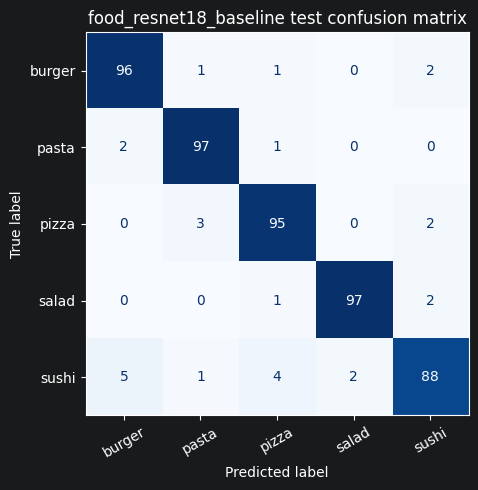

Saved metrics: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\food_resnet18_baseline_metrics.csv
Saved confusion matrix: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\food_resnet18_baseline_confusion_matrix.png


In [7]:
food_resnet18 = build_model("resnet18", len(FOOD_CLASSES), freeze_backbone=False)
food_resnet18, food_resnet18_history = train_model(
    food_resnet18,
    food_loaders,
    OUTPUT_DIR / "food_resnet18_baseline_model.pth",
    run_name="food_resnet18_baseline",
    classes=FOOD_CLASSES,
    arch="resnet18",
    epochs=FOOD_RESNET18_EPOCHS,
    lr=1e-4,
)

food_resnet18_metrics = evaluate_model(
    food_resnet18,
    food_loaders,
    FOOD_CLASSES,
    "food_resnet18_baseline",
    OUTPUT_DIR / "food_resnet18_baseline_metrics.csv",
    OUTPUT_DIR / "food_resnet18_baseline_confusion_matrix.png",
)


## 7. Train EfficientNet-B0 food classifier

  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

food_efficientnet_b0 epoch 01/8 | train acc 0.807 | val acc 0.938


  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

food_efficientnet_b0 epoch 08/8 | train acc 0.992 | val acc 0.964
Best validation accuracy for food_efficientnet_b0: 0.9680
Saved best checkpoint: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\food_model.pth


  0%|          | 0/16 [00:00<?, ?it/s]

food_efficientnet_b0 val accuracy: 0.9680


  0%|          | 0/16 [00:00<?, ?it/s]

food_efficientnet_b0 test accuracy: 0.9640


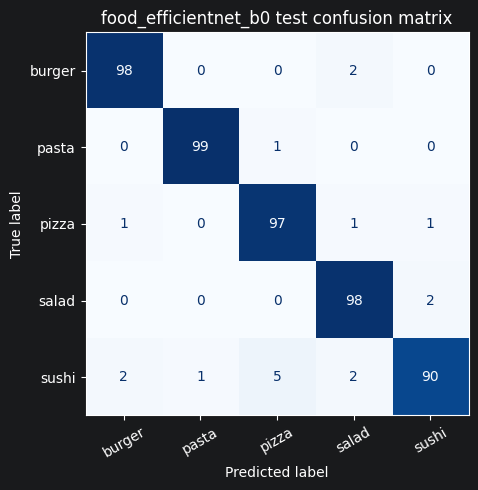

Saved metrics: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\food_metrics.csv
Saved confusion matrix: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\food_confusion_matrix.png


In [8]:
food_model = build_model("efficientnet_b0", len(FOOD_CLASSES), freeze_backbone=False)
food_model, food_history = train_model(
    food_model,
    food_loaders,
    OUTPUT_DIR / "food_model.pth",
    run_name="food_efficientnet_b0",
    classes=FOOD_CLASSES,
    arch="efficientnet_b0",
    epochs=FOOD_EFFICIENTNET_EPOCHS,
    lr=1e-4,
)

food_metrics = evaluate_model(
    food_model,
    food_loaders,
    FOOD_CLASSES,
    "food_efficientnet_b0",
    OUTPUT_DIR / "food_metrics.csv",
    OUTPUT_DIR / "food_confusion_matrix.png",
)


## 8. Train EfficientNet-B0 portion classifier

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

portion_efficientnet_b0 epoch 01/10 | train acc 0.314 | val acc 0.444


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

portion_efficientnet_b0 epoch 10/10 | train acc 0.570 | val acc 0.444
Best validation accuracy for portion_efficientnet_b0: 0.4667
Saved best checkpoint: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\portion_model.pth


  0%|          | 0/3 [00:00<?, ?it/s]

portion_efficientnet_b0 val accuracy: 0.4667


  0%|          | 0/3 [00:00<?, ?it/s]

portion_efficientnet_b0 test accuracy: 0.3333


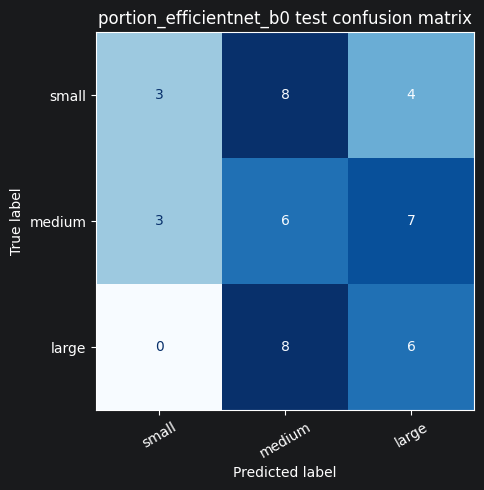

Saved metrics: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\portion_metrics.csv
Saved confusion matrix: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\portion_confusion_matrix.png


In [9]:
portion_model = build_model("efficientnet_b0", len(PORTION_CLASSES), freeze_backbone=True)
portion_model, portion_history = train_model(
    portion_model,
    portion_loaders,
    OUTPUT_DIR / "portion_model.pth",
    run_name="portion_efficientnet_b0",
    classes=PORTION_CLASSES,
    arch="efficientnet_b0",
    epochs=PORTION_EPOCHS,
    lr=3e-4,
)

portion_metrics = evaluate_model(
    portion_model,
    portion_loaders,
    PORTION_CLASSES,
    "portion_efficientnet_b0",
    OUTPUT_DIR / "portion_metrics.csv",
    OUTPUT_DIR / "portion_confusion_matrix.png",
)


## 9. Rule-based calorie mapping and final pipeline helpers

In [10]:
calorie_map = {
    ("salad", "small"): "low",
    ("salad", "medium"): "low",
    ("salad", "large"): "medium",
    ("sushi", "small"): "low",
    ("sushi", "medium"): "medium",
    ("sushi", "large"): "high",
    ("pizza", "small"): "medium",
    ("pizza", "medium"): "high",
    ("pizza", "large"): "high",
    ("burger", "small"): "medium",
    ("burger", "medium"): "high",
    ("burger", "large"): "high",
    ("pasta", "small"): "medium",
    ("pasta", "medium"): "high",
    ("pasta", "large"): "high",
}


@torch.no_grad()
def predict_single_image(
    model: nn.Module,
    image_path: Path,
    transform,
    classes: List[str],
) -> Tuple[str, float]:
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(DEVICE)
    logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    return classes[pred_idx], float(probs[pred_idx])


def predict_calorie_pipeline(image_path_value: str) -> dict:
    image_path = resolve_image_path(image_path_value)
    predicted_food, food_confidence = predict_single_image(
        food_model,
        image_path,
        eval_transform,
        FOOD_CLASSES,
    )
    predicted_portion, portion_confidence = predict_single_image(
        portion_model,
        image_path,
        eval_transform,
        PORTION_CLASSES,
    )
    predicted_calorie_level = calorie_map[(predicted_food, predicted_portion)]
    return {
        "predicted_food": predicted_food,
        "food_confidence": food_confidence,
        "predicted_portion": predicted_portion,
        "portion_confidence": portion_confidence,
        "predicted_calorie_level": predicted_calorie_level,
    }


print("Rule-based calorie map ready.")


Rule-based calorie map ready.


## 10. Train Nutrition5k direct calorie-level baseline

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

nutrition5k_efficientnet_b0_baseline epoch 01/8 | train acc 0.389 | val acc 0.278


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

nutrition5k_efficientnet_b0_baseline epoch 08/8 | train acc 0.689 | val acc 0.333
Best validation accuracy for nutrition5k_efficientnet_b0_baseline: 0.3333
Saved best checkpoint: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\nutrition5k_baseline_model.pth


  0%|          | 0/2 [00:00<?, ?it/s]

nutrition5k_efficientnet_b0_baseline val accuracy: 0.3333


  0%|          | 0/2 [00:00<?, ?it/s]

nutrition5k_efficientnet_b0_baseline test accuracy: 0.5000


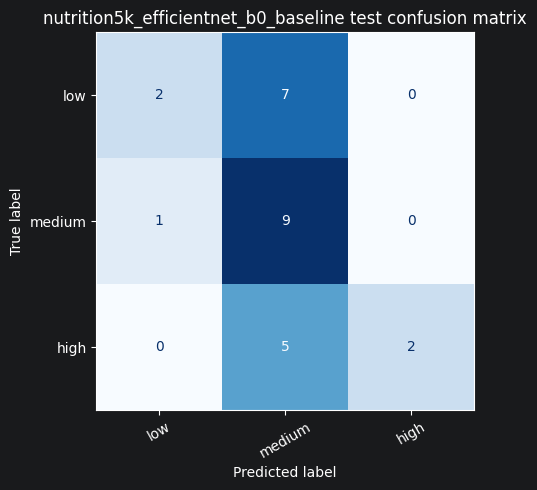

Saved metrics: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\nutrition5k_metrics.csv
Saved confusion matrix: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\nutrition5k_confusion_matrix.png


In [11]:
nutrition5k_model = build_model("efficientnet_b0", len(CALORIE_CLASSES), freeze_backbone=True)
nutrition5k_model, nutrition_history = train_model(
    nutrition5k_model,
    nutrition_loaders,
    OUTPUT_DIR / "nutrition5k_baseline_model.pth",
    run_name="nutrition5k_efficientnet_b0_baseline",
    classes=CALORIE_CLASSES,
    arch="efficientnet_b0",
    epochs=NUTRITION5K_EPOCHS,
    lr=3e-4,
)

nutrition5k_metrics = evaluate_model(
    nutrition5k_model,
    nutrition_loaders,
    CALORIE_CLASSES,
    "nutrition5k_efficientnet_b0_baseline",
    OUTPUT_DIR / "nutrition5k_metrics.csv",
    OUTPUT_DIR / "nutrition5k_confusion_matrix.png",
)


## 11. Save final pipeline example predictions

In [12]:
EXAMPLE_COUNT = 30

examples_df = food_df[food_df["split"] == "test"].sample(
    n=min(EXAMPLE_COUNT, (food_df["split"] == "test").sum()),
    random_state=SEED,
)

example_rows = []
for _, row in tqdm(examples_df.iterrows(), total=len(examples_df)):
    prediction = predict_calorie_pipeline(row["image_path"])
    true_portion = row["portion_label"] if "portion_label" in row and pd.notna(row["portion_label"]) else ""
    true_rule_calorie = ""
    if true_portion in PORTION_CLASSES:
        true_rule_calorie = calorie_map[(row["food_label"], true_portion)]

    example_rows.append(
        {
            "image_path": row["image_path"],
            "true_food": row["food_label"],
            "true_portion": true_portion,
            "true_rule_calorie_level": true_rule_calorie,
            **prediction,
        }
    )

final_examples = pd.DataFrame(example_rows)
final_examples.to_csv(OUTPUT_DIR / "final_pipeline_examples.csv", index=False)
display(final_examples.head(10))
print(f"Saved examples: {OUTPUT_DIR / 'final_pipeline_examples.csv'}")


  0%|          | 0/30 [00:00<?, ?it/s]

,image_path,true_food,true_portion,true_rule_calorie_level,predicted_food,food_confidence,predicted_portion,portion_confidence,predicted_calorie_level
0,data/food101_subset/salad/salad_0561.jpg,salad,,,salad,0.999924,medium,0.405837,low
1,data/food101_subset/burger/burger_0806.jpg,burger,medium,high,burger,0.996531,medium,0.400899,high
2,data/food101_subset/salad/salad_0414.jpg,salad,large,medium,salad,0.999351,medium,0.417573,low
3,data/food101_subset/pasta/pasta_0700.jpg,pasta,,,pasta,0.997197,small,0.414030,medium
4,data/food101_subset/pasta/pasta_0162.jpg,pasta,,,pasta,0.997993,medium,0.454373,high
5,data/food101_subset/salad/salad_0072.jpg,salad,,,salad,0.999775,medium,0.475892,low
6,data/food101_subset/salad/salad_0770.jpg,salad,,,salad,0.999055,medium,0.395623,low
7,data/food101_subset/pasta/pasta_0428.jpg,pasta,small,medium,pasta,0.977346,medium,0.391140,high
8,data/food101_subset/burger/burger_0161.jpg,burger,,,burger,0.999863,medium,0.408625,high
9,data/food101_subset/sushi/sushi_0876.jpg,sushi,,,sushi,0.999946,large,0.591387,high


Saved examples: C:\Users\Kai Xu\PycharmProjects\ECS111Final\outputs\final_pipeline_examples.csv


## 12. Final output check

In [13]:
expected_outputs = [
    "food_model.pth",
    "portion_model.pth",
    "nutrition5k_baseline_model.pth",
    "food_confusion_matrix.png",
    "portion_confusion_matrix.png",
    "nutrition5k_confusion_matrix.png",
    "food_metrics.csv",
    "portion_metrics.csv",
    "nutrition5k_metrics.csv",
    "final_pipeline_examples.csv",
]

for filename in expected_outputs:
    path = OUTPUT_DIR / filename
    print(f"{filename}: {'OK' if path.exists() else 'missing'}")

print("\nFinal model pipeline:")
print("image -> EfficientNet-B0 food classifier -> predicted food")
print("image -> EfficientNet-B0 portion classifier -> predicted portion")
print("predicted food + predicted portion -> rule-based calorie map -> calorie level")


food_model.pth: OK
portion_model.pth: OK
nutrition5k_baseline_model.pth: OK
food_confusion_matrix.png: OK
portion_confusion_matrix.png: OK
nutrition5k_confusion_matrix.png: OK
food_metrics.csv: OK
portion_metrics.csv: OK
nutrition5k_metrics.csv: OK
final_pipeline_examples.csv: OK

Final model pipeline:
image -> EfficientNet-B0 food classifier -> predicted food
image -> EfficientNet-B0 portion classifier -> predicted portion
predicted food + predicted portion -> rule-based calorie map -> calorie level
